In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X = np.linspace(1, 12, 12).reshape(4,3)
X = np.hstack([[[0], [0], [0], [0]], [[0], [0], [0], [0]], [[1], [1], [1], [1]], X, [[1], [1], [1], [1]]])
X

array([[ 0.,  0.,  1.,  1.,  2.,  3.,  1.],
       [ 0.,  0.,  1.,  4.,  5.,  6.,  1.],
       [ 0.,  0.,  1.,  7.,  8.,  9.,  1.],
       [ 0.,  0.,  1., 10., 11., 12.,  1.]])

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

Xd = pca.fit_transform(X)
Xd

array([[-7.79422863,  0.        ],
       [-2.59807621,  0.        ],
       [ 2.59807621,  0.        ],
       [ 7.79422863, -0.        ]])

In [4]:
pca.explained_variance_ratio_

array([1., 0.])

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

X_train, y_train, X_test, y_test = mnist.data[:60000], mnist.target[:60000], mnist.data[60000:], mnist.target[60000:] 

In [6]:
pca = PCA()
pca.fit(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

d

np.int64(154)

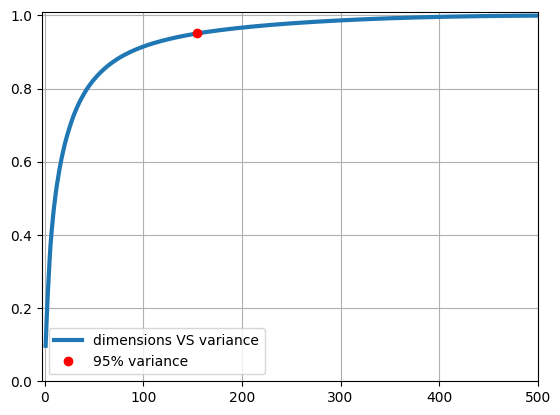

In [7]:
plt.plot(np.linspace(1, len(cumsum), len(cumsum)), cumsum, linewidth=3, label='dimensions VS variance')
plt.plot(d, cumsum[d], 'ro', label='95% variance')

plt.xlim(-3, 500)
plt.ylim(0, 1.01)
plt.grid(True)
plt.legend()

plt.show()

In [8]:
#simplier option
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

pca.n_components_

np.int64(154)

In [9]:
#optimal solution
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

cls = Pipeline([('pca', PCA(random_state=52)), ('rf', RandomForestClassifier(random_state=52))])

params = [{'pca__n_components' : np.arange(30, 120), 'rf__n_estimators': np.arange(30, 500)}]

rand_search = RandomizedSearchCV(cls, params, cv=3, n_iter=10, random_state=52, n_jobs=12)
rand_search.fit(X_train[:2000], y_train[:2000])

,estimator,Pipeline(step...m_state=52))])
,param_distributions,"[{'pca__n_components': array([ 30, ...17, 118, 119]), 'rf__n_estimators': array([ 30, ... 498, 499])}]"
,n_iter,10
,scoring,None
,n_jobs,12
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,52
,error_score,nan


In [10]:
pd.DataFrame(rand_search.cv_results_).sort_values(by='mean_test_score', ascending=False).head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_rf__n_estimators,param_pca__n_components,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,3.271776,0.145562,0.048021,0.002643,388,53,"{'rf__n_estimators': 388, 'pca__n_components':...",0.890555,0.862069,0.888889,0.880504,0.013053,1
6,3.930750,0.051041,0.047327,0.001169,482,47,"{'rf__n_estimators': 482, 'pca__n_components':...",0.890555,0.868066,0.882883,0.880501,0.009334,2
9,3.477108,0.152271,0.032216,0.000164,347,116,"{'rf__n_estimators': 347, 'pca__n_components':...",0.884558,0.874063,0.876877,0.878499,0.004435,3
4,3.902919,0.352328,0.047839,0.002494,409,77,"{'rf__n_estimators': 409, 'pca__n_components':...",0.884558,0.859070,0.888889,0.877506,0.013155,4
8,2.764497,0.108943,0.025746,0.000563,259,88,"{'rf__n_estimators': 259, 'pca__n_components':...",0.892054,0.856072,0.879880,0.876002,0.014943,5


In [11]:
rand_search.best_params_

{'rf__n_estimators': np.int64(388), 'pca__n_components': np.int64(53)}

In [ ]:
#reconstruction
X_reconstructed = pca.inverse_transform(X_reduced)

print(X_train.shape)
print(X_reduced.shape)
print(X_reconstructed.shape)
#variance loss 5% (images with the lower quality)

(60000, 784)
(60000, 154)
(60000, 784)


In [15]:
rnd_pca = PCA(svd_solver='randomized', n_components=154, random_state=52)

(rnd_pca.fit_transform(X_train)).shape


(60000, 154)

#### incremental PCA

In [16]:
from sklearn.decomposition import IncrementalPCA

inc_pca = IncrementalPCA(n_components=154)
batches = 100

for X_batch in np.array_split(X_train, batches):
    inc_pca.partial_fit(X_batch)
    
X_batch_reduced = inc_pca.transform(X_train[:2000])
X_batch_reduced.shape

(2000, 154)

In [ ]:
#using memmap for data on the disk storage
X_mmap = np.memmap('mnist.mmap', dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

In [34]:
X_mmap = np.memmap('mnist.mmap', dtype='float32', mode='readonly').reshape(-1, 784)

n_inst = X_mmap.shape[0] // batches
inc_pca = IncrementalPCA(batch_size=n_inst, n_components=154)
inc_pca.fit(X_mmap)


X_batch_reduced = inc_pca.transform(X_train[:2000])
X_batch_reduced.shape

(2000, 154)

## Random projection

In [41]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, eps = 5000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=eps)
d

np.int64(7300)

In [43]:
n = 20000
rng = np.random.default_rng(seed=52)
P = rng.standard_normal((d, n)) / np.sqrt(d)

X = rng.standard_normal((m, n)) 
X_reduced = X @ P.T

print(X.shape)
X_reduced.shape

(5000, 20000)


(5000, 7300)

In [44]:
X_reduced

array([[-1.94197452,  0.15423601,  0.32901287, ...,  2.85310446,
         1.11936006,  0.54788919],
       [ 2.51581617, -1.19083108, -2.55823896, ...,  0.16178897,
        -1.51109439,  0.95674917],
       [ 2.94631048, -0.5627226 ,  1.88070308, ...,  0.56969476,
         0.52665633, -1.81203123],
       ...,
       [-2.80644144,  1.89107343,  0.14644713, ...,  0.37238764,
        -1.43505658,  0.72395716],
       [-2.22863823, -1.95729424,  2.69049881, ...,  1.06649261,
        -0.69417075, -0.67978158],
       [-1.43413851,  0.89568447,  1.14689485, ..., -4.16195755,
         1.86094893,  1.81089104]], shape=(5000, 7300))

In [50]:
from sklearn.random_projection import GaussianRandomProjection, SparseRandomProjection

grp = GaussianRandomProjection(eps=eps, random_state=52)
X_reduced1 = grp.fit_transform(X)
print(X_reduced.shape)

(5000, 7300)


In [54]:
srp = SparseRandomProjection(eps=eps, random_state=52)
X_reduced = srp.fit_transform(X)
print(X_reduced.shape)

(5000, 7300)


In [51]:
components_pinv = np.linalg.pinv(grp.components_)
X_recovered = X_reduced1 @ components_pinv.T

In [53]:
X_recovered.shape

(5000, 20000)

## LLE

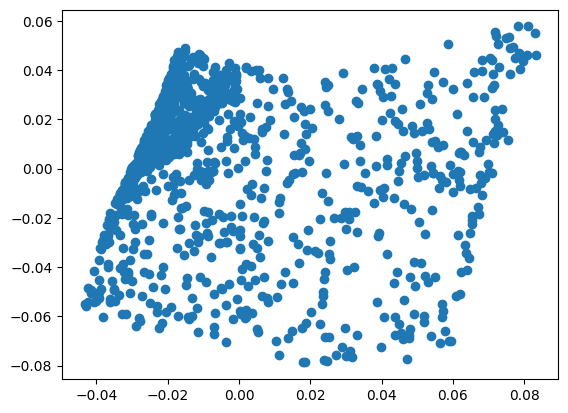

In [100]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=52)
lle = LocallyLinearEmbedding(n_neighbors=13, n_components=2, random_state=52)

X_unrolled = lle.fit_transform(X_swiss)

plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1], )

## EX 9

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train, X_test, y_test = mnist.data[:60000], mnist.target[:60000], mnist.data[60000:], mnist.target[60000:] 

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA 
from sklearn.pipeline import Pipeline

rf_cls1 = RandomForestClassifier(random_state=53)
rf_cls2 = Pipeline([('pca', PCA(n_components=0.95)), ('rf', RandomForestClassifier(random_state=53))])

In [14]:
#28s
rf_cls1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
#1m 28s                     outdated:(PCA takes a lot of time)
rf_cls2.fit(X_train, y_train)

,steps,"[('pca', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


In [7]:
X_reduced = PCA(n_components=0.95).fit_transform(X_train)
rf_cls3 = RandomForestClassifier(random_state=55)

In [ ]:
# PCA is not a reason of slowliness  
rf_cls3.fit(X_reduced, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
print(rf_cls1.score(X_test, y_test))
print(rf_cls2.score(X_test, y_test))

0.9698
0.9466


In [16]:
from sklearn.linear_model import SGDClassifier

sgd_cls1 = SGDClassifier(random_state=52)
sgd_cls2 = Pipeline([('pca', PCA(n_components=0.95)), ('sgd', SGDClassifier(random_state=52))])

In [ ]:
#1m 28s
sgd_cls1.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
#22s
sgd_cls2.fit(X_train, y_train)

,steps,"[('pca', ...), ('sgd', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


In [19]:
print(sgd_cls1.score(X_test, y_test))
print(sgd_cls2.score(X_test, y_test))

0.8952
0.8936


## EX 9

In [20]:
X_train, y_train = X_train[:5000], y_train[:5000]

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=52)
X_reduced = tsne.fit_transform(X_train)

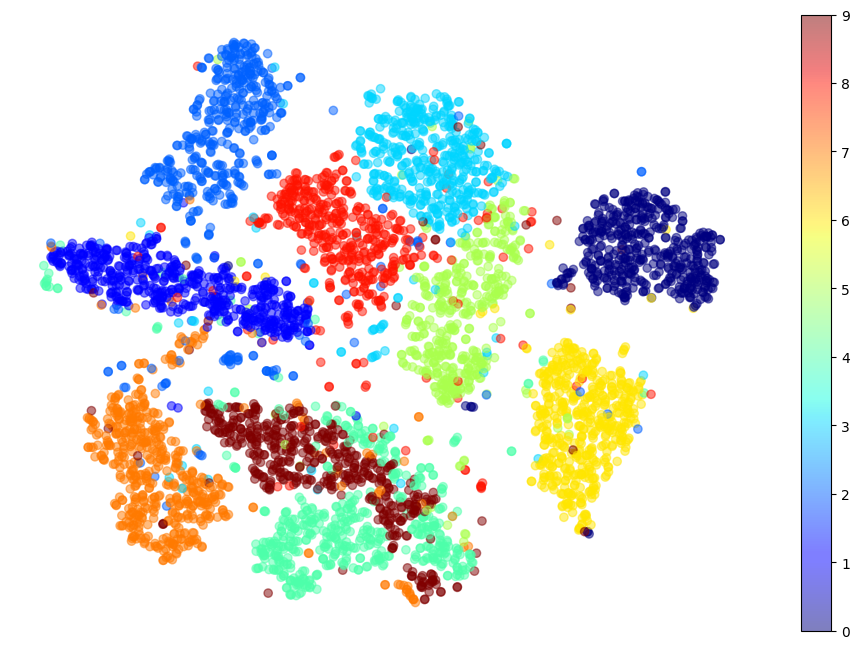

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(X_reduced[:,0], X_reduced[:,1], alpha=0.5, cmap='jet', c=y_train.astype(np.int8))

plt.colorbar()
plt.axis('off')

plt.show()

In [36]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

def plot_digits(X, y, min_distance=0.04, images=None, figsize=(13, 10)):
    X_normilized = MinMaxScaler().fit_transform(X)
    neighbors = np.array([[10., 10.]])
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    digits = np.unique(y)
    for digit in digits:
        plt.scatter(X_normilized[y==digit, 0], X_normilized[y==digit, 1], c=[cmap(float(digit)/9)], alpha=0.5)
    plt.axis('off')
    ax = plt.gca()
    for index, image_coord in enumerate(X_normilized):
        closest_distance = np.linalg.norm(neighbors - image_coord, axis=1).min()
        if closest_distance > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]
            if images is None:
                plt.text(image_coord[0], image_coord[1], str(int(y[index])), color=cmap(float(y[index])/9), fontdict={'weight' : 'bold', 'size' : 16})
            else:
                image = images[index].reshape(28, 28)
                imagebox = AnnotationBbox(OffsetImage(image, cmap='binary'), image_coord)
                ax.add_artist(imagebox)

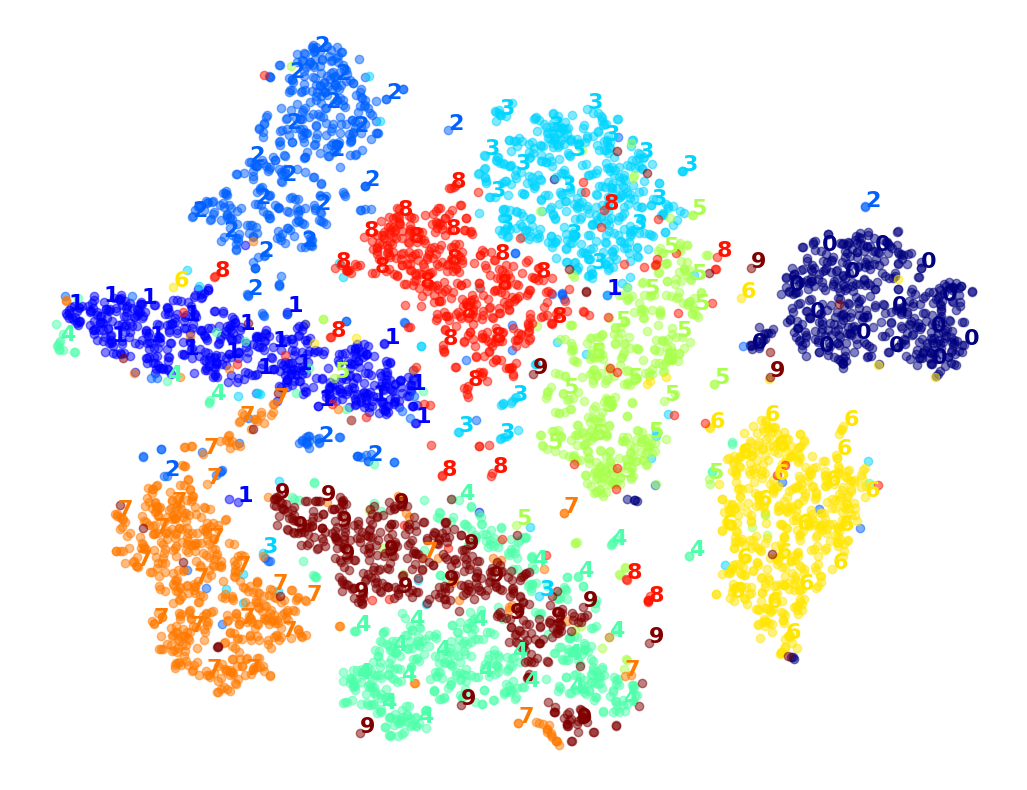

In [37]:
plot_digits(X_reduced, y_train)

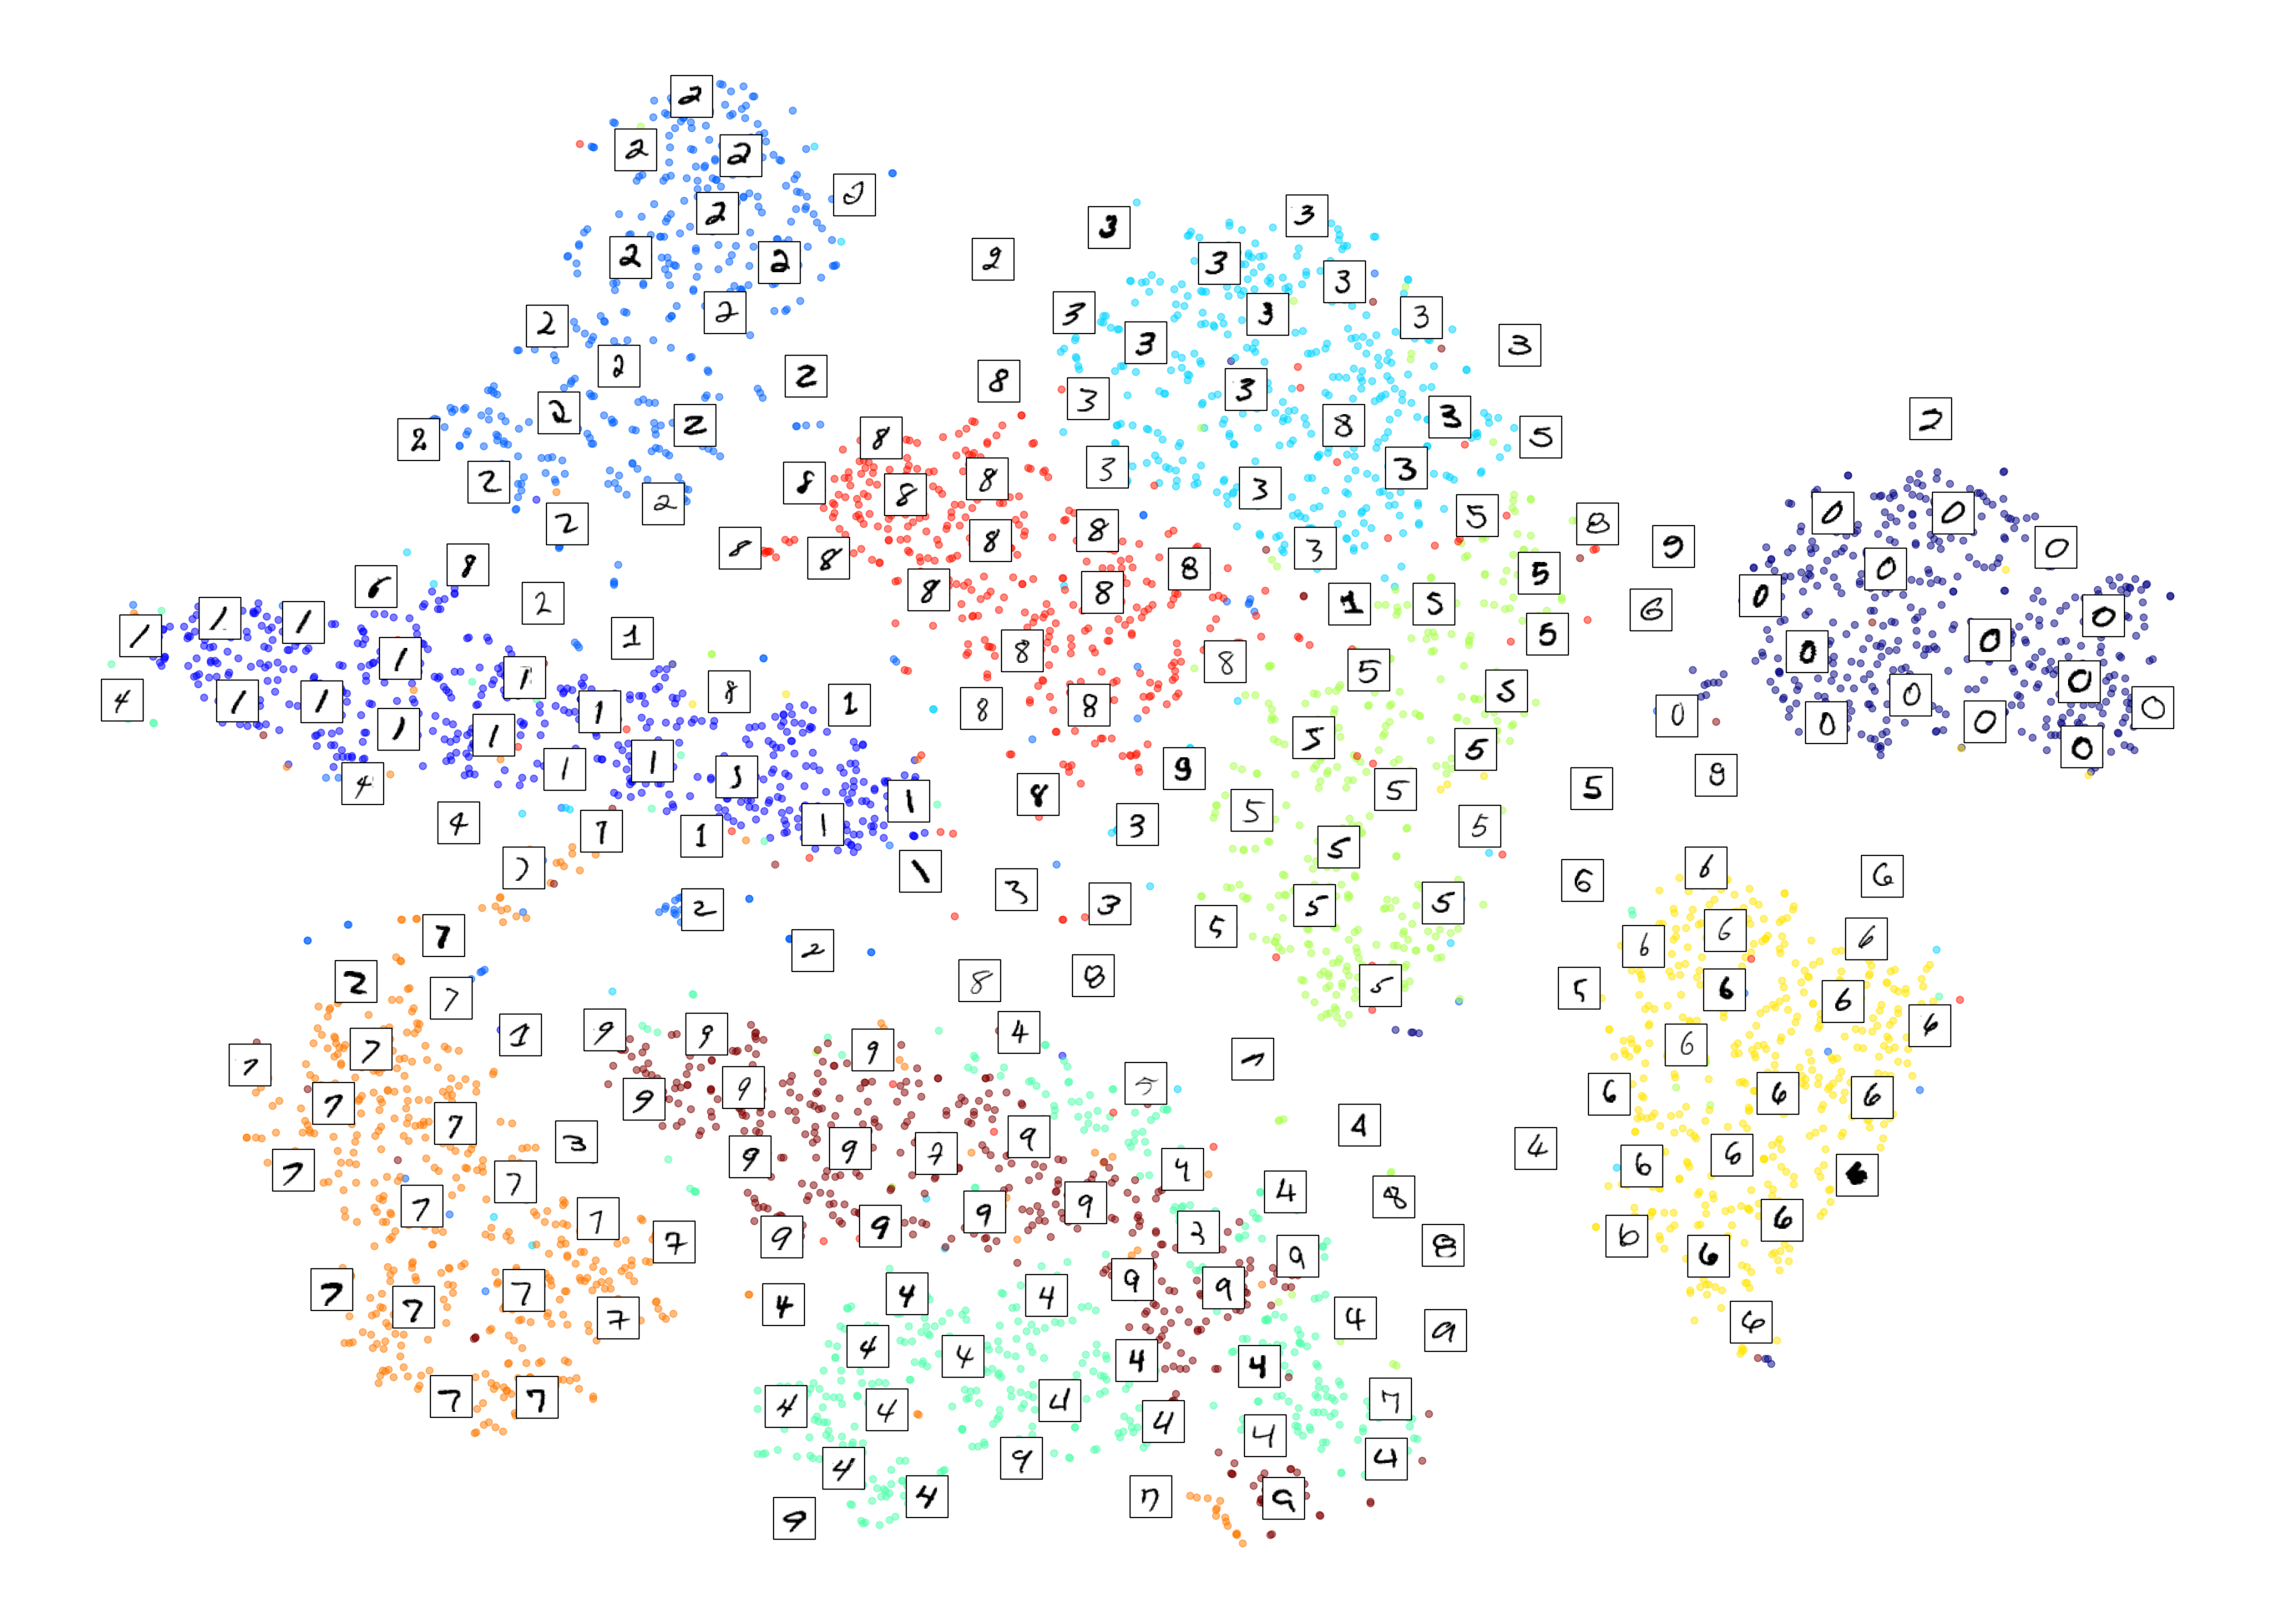

In [38]:
plot_digits(X_reduced, y_train, images=X_train, figsize=(35, 25))

In [ ]:
#7m 35s
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import MDS
from sklearn.decomposition import PCA

X_lle = LocallyLinearEmbedding(n_components=2, random_state=52).fit_transform(X_train)
X_mds = MDS(n_components=2, random_state=52).fit_transform(X_train)
X_pca = PCA(n_components=2, random_state=52).fit_transform(X_train)

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


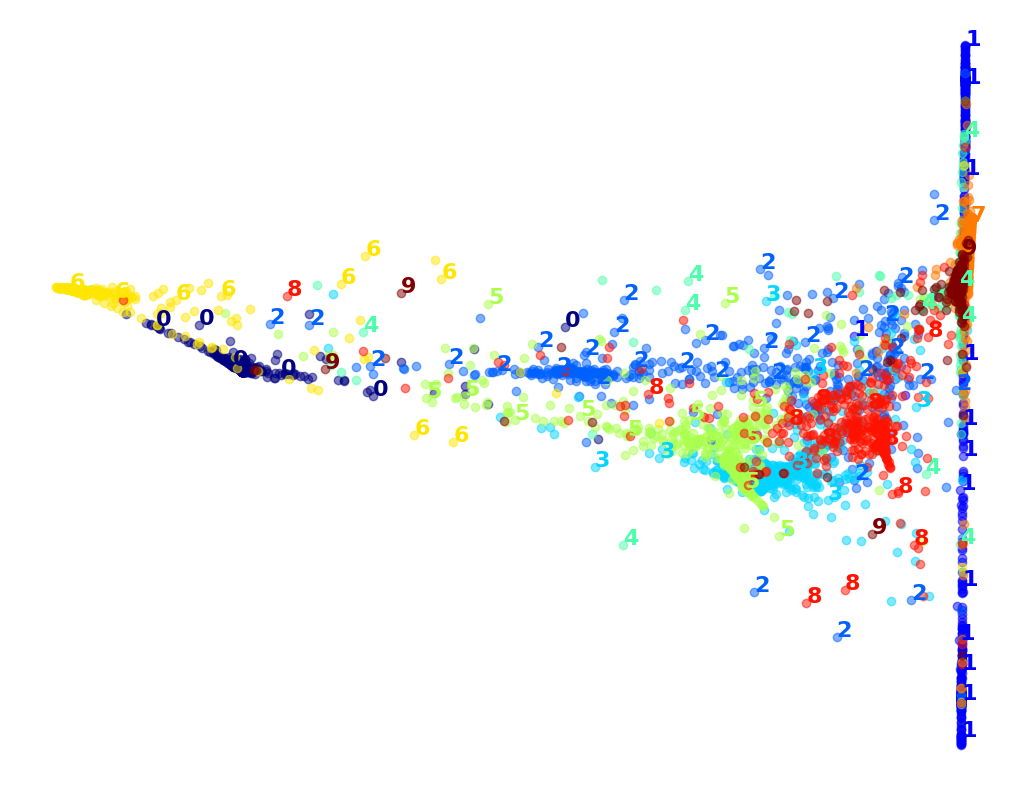

In [42]:
plot_digits(X_lle, y_train)

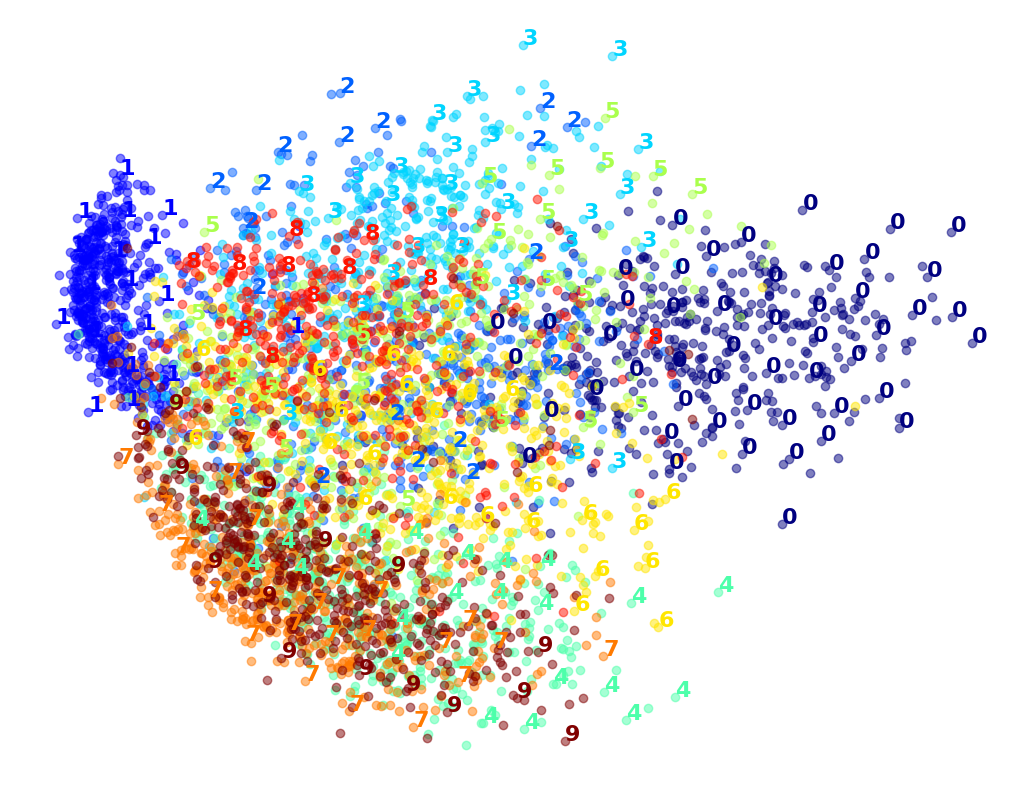

In [43]:
plot_digits(X_pca, y_train)

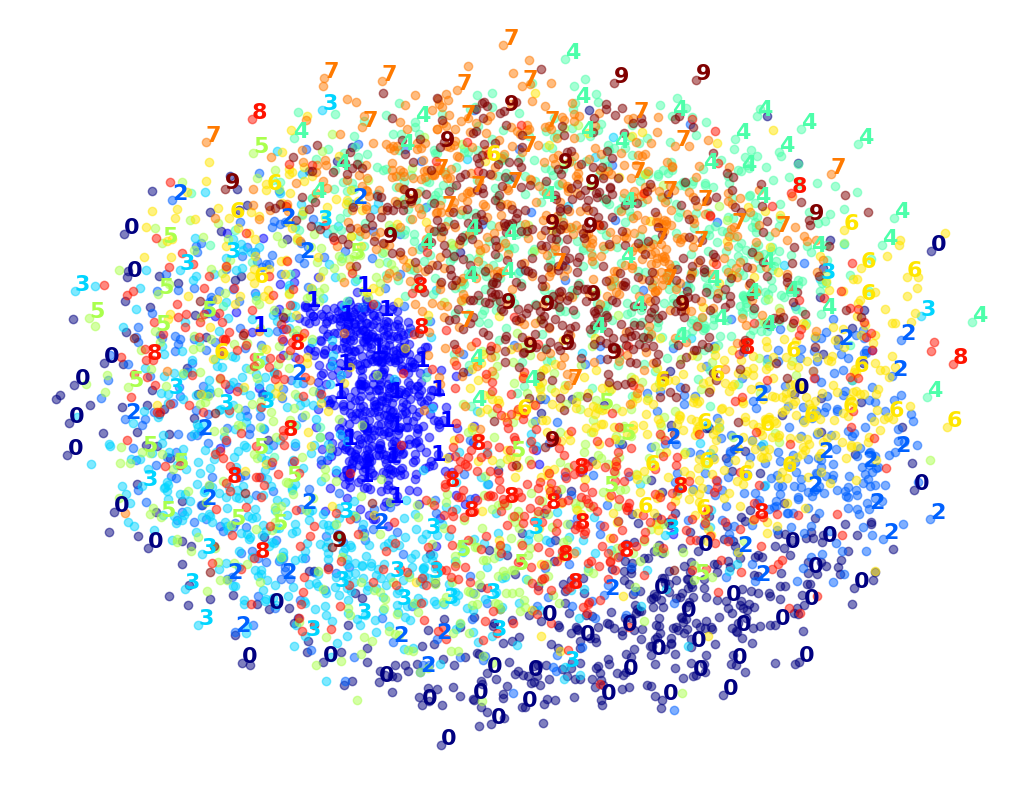

In [44]:
plot_digits(X_mds, y_train)